In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

df = pd.read_csv(
    "apartments_for_rent_classified_10K.csv",
    encoding="latin1",
    sep=";",
    on_bad_lines="skip"
)

conn = sqlite3.connect("apartments.db")

df.to_sql("apartments", conn, if_exists="replace", index=False)

df_db = pd.read_sql("SELECT * FROM apartments", conn)

df_db.head()

df.shape

(10000, 22)

In [2]:
df.columns

Index(['id', 'category', 'title', 'body', 'amenities', 'bathrooms', 'bedrooms',
       'currency', 'fee', 'has_photo', 'pets_allowed', 'price',
       'price_display', 'price_type', 'square_feet', 'address', 'cityname',
       'state', 'latitude', 'longitude', 'source', 'time'],
      dtype='object')

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             10000 non-null  int64  
 1   category       10000 non-null  object 
 2   title          10000 non-null  object 
 3   body           10000 non-null  object 
 4   amenities      6451 non-null   object 
 5   bathrooms      9966 non-null   float64
 6   bedrooms       9993 non-null   float64
 7   currency       10000 non-null  object 
 8   fee            10000 non-null  object 
 9   has_photo      10000 non-null  object 
 10  pets_allowed   8252 non-null   object 
 11  price          10000 non-null  int64  
 12  price_display  10000 non-null  object 
 13  price_type     10000 non-null  object 
 14  square_feet    10000 non-null  int64  
 15  address        6673 non-null   object 
 16  cityname       9923 non-null   object 
 17  state          9923 non-null   object 
 18  latitud

In [4]:
df.isnull().sum()

id                  0
category            0
title               0
body                0
amenities        3549
bathrooms          34
bedrooms            7
currency            0
fee                 0
has_photo           0
pets_allowed     1748
price               0
price_display       0
price_type          0
square_feet         0
address          3327
cityname           77
state              77
latitude           10
longitude          10
source              0
time                0
dtype: int64

In [5]:
df.head()

,id,category,title,body,amenities,bathrooms,bedrooms,currency,fee,has_photo,...,price_display,price_type,square_feet,address,cityname,state,latitude,longitude,source,time
0,5668626895,housing/rent/apartment,"Studio apartment 2nd St NE, Uhland Terrace NE,...","This unit is located at second St NE, Uhland T...",NaN,NaN,0.0,USD,No,Thumbnail,...,$790,Monthly,101,NaN,Washington,DC,38.9057,-76.9861,RentLingo,1577359415
1,5664597177,housing/rent/apartment,Studio apartment 814 Schutte Road,"This unit is located at 814 Schutte Road, Evan...",NaN,NaN,1.0,USD,No,Thumbnail,...,$425,Monthly,106,814 Schutte Rd,Evansville,IN,37.9680,-87.6621,RentLingo,1577017063
2,5668626833,housing/rent/apartment,"Studio apartment N Scott St, 14th St N, Arling...","This unit is located at N Scott St, 14th St N,...",NaN,1.0,0.0,USD,No,Thumbnail,...,"$1,390",Monthly,107,NaN,Arlington,VA,38.8910,-77.0816,RentLingo,1577359410
3,5659918074,housing/rent/apartment,Studio apartment 1717 12th Ave,"This unit is located at 1717 12th Ave, Seattle...",NaN,1.0,0.0,USD,No,Thumbnail,...,$925,Monthly,116,1717 12th Avenue,Seattle,WA,47.6160,-122.3275,RentLingo,1576667743
4,5668626759,housing/rent/apartment,"Studio apartment Washington Blvd, N Cleveland ...","This unit is located at Washington Blvd, N Cle...",NaN,NaN,0.0,USD,No,Thumbnail,...,$880,Monthly,125,NaN,Arlington,VA,38.8738,-77.1055,RentLingo,1577359401


In [6]:
df_clean = df.copy()

In [7]:
df_clean.duplicated().sum()

0

In [8]:
df_clean[['price', 'square_feet', 'bedrooms', 'bathrooms', 'cityname', 'state', 'latitude', 'longitude']].isnull().sum()

price           0
square_feet     0
bedrooms        7
bathrooms      34
cityname       77
state          77
latitude       10
longitude      10
dtype: int64

In [9]:
df_clean = df_clean.dropna(subset=['cityname', 'state', 'latitude', 'longitude'])

In [10]:
df_clean['bedrooms'] = df_clean['bedrooms'].fillna(df_clean['bedrooms'].median())
df_clean['bathrooms'] = df_clean['bathrooms'].fillna(df_clean['bathrooms'].median())

In [11]:
df_clean['price'].describe()

count     9923.000000
mean      1486.135644
std       1078.112000
min        200.000000
25%        949.000000
50%       1270.000000
75%       1695.000000
max      52500.000000
Name: price, dtype: float64

In [12]:
df_clean = df_clean[df_clean['price'] > 0]

In [13]:
df_clean['square_feet'].describe()

count     9923.000000
mean       946.152474
std        657.216433
min        101.000000
25%        649.000000
50%        803.000000
75%       1100.000000
max      40000.000000
Name: square_feet, dtype: float64

In [14]:
df_clean = df_clean[df_clean['square_feet'] > 0]

In [15]:
df_clean[['bedrooms', 'bathrooms']].describe()

,bedrooms,bathrooms
count,9923.000000,9923.000000
mean,1.744231,1.379472
std,0.942451,0.615581
min,0.000000,1.000000
25%,1.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,9.000000,8.500000


In [16]:
df_clean = df_clean[df_clean['bedrooms'] >= 0]
df_clean = df_clean[df_clean['bathrooms'] >= 0]

In [17]:
df_clean.shape

(9923, 22)

In [18]:
df_clean.to_csv("apartments_cleaned.csv", index=False)

In [19]:
df_plot = df_clean[
    (df_clean['price'] < 5000) &
    (df_clean['square_feet'] < 3000)
]

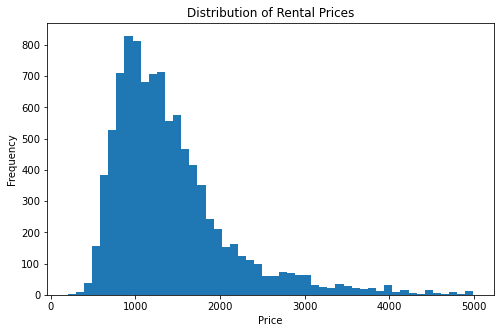

In [20]:
plt.figure(figsize=(8,5))
plt.hist(df_plot['price'], bins=50)
plt.title("Distribution of Rental Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

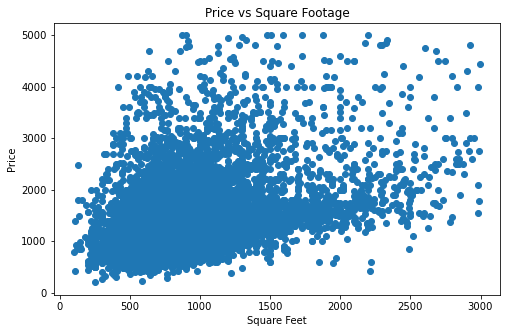

In [21]:
plt.figure(figsize=(8,5))
plt.scatter(df_plot['square_feet'], df_plot['price'])
plt.title("Price vs Square Footage")
plt.xlabel("Square Feet")
plt.ylabel("Price")
plt.show()

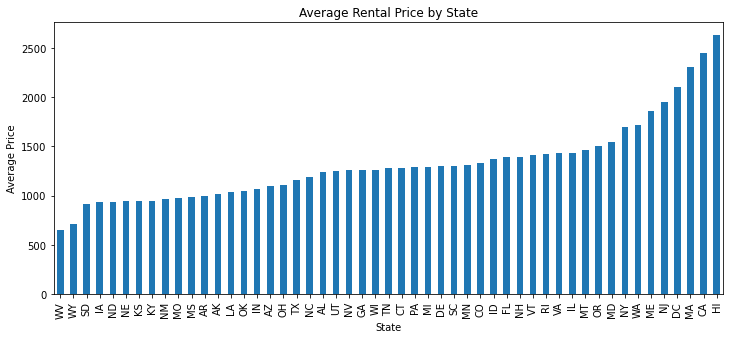

In [22]:
avg_price_state = df_plot.groupby('state')['price'].mean().sort_values()

plt.figure(figsize=(12,5))
avg_price_state.plot(kind='bar')
plt.title("Average Rental Price by State")
plt.xlabel("State")
plt.ylabel("Average Price")
plt.show()